<a href="https://colab.research.google.com/github/AmrKhaled545/Retail-Demand-Forecasting-Project/blob/main/Retail_Demand_Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Retail Demand Forecasting — Walmart M5 Sales Pipeline

## Project Overview

This notebook implements an end-to-end retail demand forecasting pipeline
built on the M5 Forecasting (Walmart) dataset. It covers data ingestion,
memory-efficient feature engineering at scale, exploratory analysis of sales
and pricing patterns, model training and comparison, and a 28-day recursive
forecast that powers the companion Streamlit application.

## Design Principles

- **Scales independently of dataset size.** Product selection (`TOP_N`) and
  processing batch size (`CHUNK_SIZE`) are decoupled — peak memory usage is
  governed only by `CHUNK_SIZE`, so `TOP_N` can be raised from 15 to 1,500+
  without changing how the pipeline runs.
- **Category-balanced by design.** Products are selected proportionally
  across categories (`FOODS`, `HOUSEHOLD`, `HOBBIES`) rather than by raw
  sales volume alone, so the model trains on a representative product mix
  instead of being dominated by the largest category.
- **Memory-aware at every stage.** Numeric and categorical columns are
  downcast to the smallest safe dtype throughout, EDA statistics are
  accumulated incrementally rather than computed on a fully materialized
  table, and intermediate frames are released as soon as they're no longer
  needed.
- **Model choice is evidence-based.** XGBoost and LightGBM are trained and
  compared on identical features and metrics; an optional LSTM baseline is
  included for completeness, with a documented rationale for why gradient
  boosting is the stronger default for this dataset.

## Notebook Structure

1. Data loading & category-balanced product selection
2. Chunked feature engineering pipeline
3. Exploratory Data Analysis
4. Data cleaning & preprocessing (recap)
5. Time-series feature engineering (recap)
6. Chronological train/test split
7. Baseline model: XGBoost
8. Model comparison: LightGBM & optional deep learning baseline
9. Recursive 28-day forecasting & deployment artifacts
10. Deployment via Streamlit


In [1]:
# Data Analysis Libraries
import pandas as pd
import numpy as np
import gc
import warnings

# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Modeling Libraries
import xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

pd.set_option('display.max_columns', None)
warnings.filterwarnings('ignore', category=FutureWarning)


In [2]:
def reduce_mem_usage(df, verbose=False):
    """Downcast numeric columns to the smallest dtype that fits, in place."""
    numerics = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']
    start_mem = df.memory_usage().sum() / 1024**2
    for col in df.columns:
        col_type = df[col].dtypes
        if col_type in numerics:
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                else:
                    df[col] = df[col].astype(np.int64)
            else:
                if c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)
    end_mem = df.memory_usage().sum() / 1024**2
    if verbose:
        print(f'Memory usage: {start_mem:.2f} MB -> {end_mem:.2f} MB '
              f'({100*(start_mem-end_mem)/start_mem:.1f}% reduction)')
    return df


def print_memory_usage(label=''):
    """Best-effort process RAM report. Falls back quietly if psutil isn't installed."""
    try:
        import psutil, os
        rss_mb = psutil.Process(os.getpid()).memory_info().rss / 1024**2
        print(f'[memory] {label}: {rss_mb:.1f} MB in use')
    except ImportError:
        pass


## Step 1 — Data Loading & Product Selection

`calendar.csv` and `sell_prices.csv` are loaded directly. `sales_train_validation.csv`
is loaded in its original *wide* format — one row per product-store
combination with one column per day — since reshaping it before selecting
products would force the full dataset into memory unnecessarily. Categorical
columns are cast to compact dtypes immediately, before any melting or
merging takes place.


In [3]:
# Getting the uploaded data from Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
DATA_DIR = '/content/drive/MyDrive/DEPI/DEPI_Grad_Project/data/'  # <-- change to your path, e.g. '/content/drive/MyDrive/DEPI/DEPI_Grad_Project/data/'

calendar = pd.read_csv(DATA_DIR + 'calendar.csv', parse_dates=['date'])
sell_prices = pd.read_csv(DATA_DIR + 'sell_prices.csv')

for c in ['weekday', 'event_name_1', 'event_type_1', 'event_name_2', 'event_type_2']:
    if c in calendar.columns:
        calendar[c] = calendar[c].astype('category')

id_dtypes = {'id': 'category', 'item_id': 'category', 'dept_id': 'category',
             'cat_id': 'category', 'store_id': 'category', 'state_id': 'category'}
sales_wide = pd.read_csv(DATA_DIR + 'sales_train_validation.csv', dtype=id_dtypes)

d_cols = [c for c in sales_wide.columns if c.startswith('d_')]
sales_wide[d_cols] = sales_wide[d_cols].astype('int16')

print('Raw wide shape:', sales_wide.shape)
print_memory_usage('after loading raw files')


Raw wide shape: (30490, 1919)
[memory] after loading raw files: 994.7 MB in use


### Product Selection: `TOP_N`, `CHUNK_SIZE`, and Category Balance

Two independent parameters control the scope and scale of this pipeline:

- **`TOP_N`** — the total number of distinct products included in training
  and forecasting.
- **`CHUNK_SIZE`** — the number of products processed together in a single
  batch.

**Category-balanced selection.** Ranking products purely by total units sold
would bias the selection toward whichever category has the most SKUs (in
this dataset, `FOODS`). To avoid under-representing `HOBBIES` and
`HOUSEHOLD`, `TOP_N` is allocated proportionally to each category's share of
unique items, and the top sellers are then drawn from *within* each
category. The breakdown of how many products came from each category is
printed below and visualized as a chart.

**Memory-independent scaling.** `TARGET_ITEMS` is split into batches of
`CHUNK_SIZE` products; each batch is melted, merged, cleaned, and
feature-engineered independently, and only the compact, feature-ready result
is retained. Peak memory therefore depends on `CHUNK_SIZE`, not on `TOP_N` —
`TOP_N` can be set to 15 or 1,500 without changing the notebook's memory
profile, only its runtime.

As a practical guideline on a free-tier Colab runtime (~12 GB RAM), keep
`CHUNK_SIZE` in the 150–250 range even when `TOP_N` exceeds 1,000.


In [5]:
# Product universe: TOP_N controls how many distinct products the
# Streamlit app will ultimately serve. CHUNK_SIZE controls peak memory
# usage during processing and is chosen independently of TOP_N.

TOP_N = 1000       # total distinct products to keep — raise freely
CHUNK_SIZE = 200    # products processed per batch — lower this if you hit memory limits

total_sales_rank = sales_wide[d_cols].sum(axis=1)  # transient, used only to rank

# A flat "top N overall" ranking is dominated by the category with the most
# SKUs. Instead we allocate TOP_N across categories proportionally to each
# category's share of unique items, then take that category's best sellers.
item_rank_by_cat = (
    sales_wide.assign(_rank=total_sales_rank)
    .groupby(['cat_id', 'item_id'], observed=True)['_rank']
    .sum()
    .reset_index()
)

category_item_counts = item_rank_by_cat.groupby('cat_id', observed=True)['item_id'].nunique()
category_quota = (category_item_counts / category_item_counts.sum() * TOP_N).round().astype(int)

# Rounding can leave the total a few products short of / over TOP_N —
# adjust the largest category so the final count matches TOP_N exactly.
quota_gap = TOP_N - category_quota.sum()
category_quota.iloc[category_quota.values.argmax()] += quota_gap


In [6]:
TARGET_ITEMS = []
for cat_id, quota in category_quota.items():
    top_items_in_category = (
        item_rank_by_cat.loc[item_rank_by_cat['cat_id'] == cat_id]
        .nlargest(quota, '_rank')['item_id']
        .tolist()
    )
    TARGET_ITEMS.extend(top_items_in_category)

print(f'Selected {len(TARGET_ITEMS)} products across {len(category_quota)} categories:')
for cat_id, quota in category_quota.items():
    print(f'  - {cat_id:<10}: {quota:>4} products selected (of {category_item_counts[cat_id]} available)')

item_chunks = [TARGET_ITEMS[i:i + CHUNK_SIZE] for i in range(0, len(TARGET_ITEMS), CHUNK_SIZE)]
print(f'\nSplit into {len(item_chunks)} chunk(s) of up to {CHUNK_SIZE} products each.')


Selected 1000 products across 3 categories:
  - HOBBIES   :  185 products selected (of 565 available)
  - HOUSEHOLD :  343 products selected (of 1047 available)
  - FOODS     :  472 products selected (of 1437 available)

Split into 5 chunk(s) of up to 200 products each.


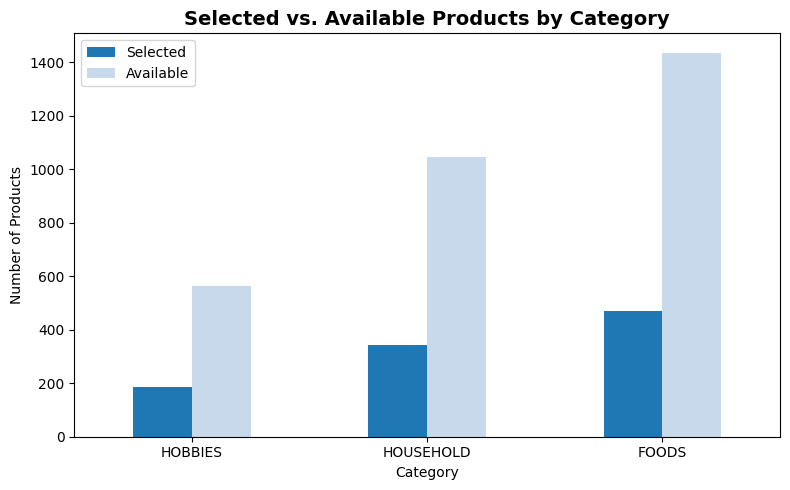

In [7]:
# --- Visualize how TOP_N was allocated across categories ---
plt.figure(figsize=(8, 5))
selection_summary = pd.DataFrame({
    'Selected': category_quota,
    'Available': category_item_counts,
})
selection_summary.plot(kind='bar', ax=plt.gca(), color=['#1f77b4', '#c7d9ea'])
plt.title('Selected vs. Available Products by Category', fontsize=14, fontweight='bold')
plt.xlabel('Category')
plt.ylabel('Number of Products')
plt.xticks(rotation=0)
plt.legend(title='')
plt.tight_layout()
plt.show()


The chart below confirms the category-balanced selection from Step 1: each
category contributes a share of `TOP_N` proportional to its number of
available products, rather than being dominated by the largest category.


## Step 2 — Chunked Feature Engineering Pipeline

Each batch of `CHUNK_SIZE` products is processed independently through
melt, merge, cleaning, and feature engineering, so memory usage never
scales with the full product/date grid at once.

For each chunk:

1. **Melt** — reshape from wide (`d_1 ... d_1913`) to long format: one row
   per item–store–day.
2. **Merge** — join with `calendar` on `d`, and with `sell_prices` (filtered
   to the same chunk) on the composite key
   `['store_id', 'item_id', 'wm_yr_wk']`; both merges are one-to-one, with no
   row duplication.
3. **Clean** — label missing calendar events explicitly, forward/backward-fill
   missing prices within each `(store_id, item_id)` series, remove exact
   duplicates, cap extreme sales outliers at the 99th percentile, and derive
   a `sales_log` column.
4. **Engineer features** — lag features (7/14/28 days) and rolling means
   (7/28 days), computed per `id` (the item–store combination, since a
   single store sells many products and each pairing is its own time
   series), plus calendar-derived features. Rows without a full 28-day lag
   history are dropped.
5. **Accumulate EDA statistics** — sums and counts only (never raw rows), so
   the analysis in the next section stays cheap regardless of how many
   chunks were processed.

Only the compact, feature-ready result of each chunk is kept; all
intermediate frames are released before the next chunk begins.


In [8]:
def fill_missing_events(df, event_cols=('event_name_1', 'event_type_1', 'event_name_2', 'event_type_2')):
    for col in event_cols:
        if col not in df.columns:
            continue
        if isinstance(df[col].dtype, pd.CategoricalDtype):
            if 'No_Event' not in df[col].cat.categories:
                df[col] = df[col].cat.add_categories('No_Event')
            df[col] = df[col].fillna('No_Event')
        else:
            df[col] = df[col].astype('object').fillna('No_Event').astype('category')
    return df


def impute_prices(df):
    # Forward/backward fill missing prices within each (store, item) series,
    # then drop rows that are still missing (genuinely inactive item/store combos).
    df['sell_price'] = df['sell_price'].astype(np.float32)
    df['sell_price'] = df.groupby(['store_id', 'item_id'], observed=True)['sell_price'] \
                          .transform(lambda x: x.ffill().bfill())
    return df


def handle_outliers_and_scale(df):
    upper_limit = df['sales'].quantile(0.99)
    df['sales'] = np.where(df['sales'] > upper_limit, upper_limit, df['sales']).astype('int16')
    df['sales_log'] = np.log1p(df['sales']).astype(np.float32)
    return df


def add_time_series_features(df, group_col='id', target='sales'):
    df = df.sort_values([group_col, 'date']).copy()

    for lag in [7, 14, 28]:
        df[f'lag_{lag}'] = df.groupby(group_col, observed=True)[target].shift(lag)

    for window in [7, 28]:
        df[f'rolling_mean_{window}'] = (
            df.groupby(group_col, observed=True)[target].shift(1).rolling(window).mean()
        )

    df['day_of_week'] = df['date'].dt.dayofweek
    df['month'] = df['date'].dt.month
    df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)
    return df


In [9]:
import time

id_vars = ['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id']

# Running EDA accumulators — small partial aggregates, never raw rows
eda_cat_sales = []
eda_weekday_sales = []
eda_daily_sales = []
eda_event_sales = []
eda_state_revenue = []
eda_store_revenue = []
eda_price_bucket_sales = []
eda_sales_hist = []
eda_heatmap = []

# Fixed bin edges (independent of any single chunk) so partial histograms
# and price buckets can be summed safely across chunks.
SALES_HIST_BIN_EDGES = np.arange(0, 42, 1)  # 0-40 units/day, overflow folded into the last bin
PRICE_BUCKET_EDGES = [0, 2, 5, 10, 20, 50, np.inf]
PRICE_BUCKET_LABELS = ['<$2', '$2-5', '$5-10', '$10-20', '$20-50', '$50+']
eda_missing_counts = pd.Series(dtype='int64')
eda_duplicates_total = 0

model_ready_chunks = []
pipeline_start = time.time()


In [10]:
for chunk_num, chunk_items in enumerate(item_chunks, start=1):
    chunk_start = time.time()
    try:
        # 1. Filter + melt just this chunk
        chunk_wide = sales_wide[sales_wide['item_id'].isin(chunk_items)]
        chunk_long = chunk_wide.melt(id_vars=id_vars, var_name='d', value_name='sales')

        # 2. Merge with calendar (on 'd') and prices (composite key, no fan-out)
        chunk_long = chunk_long.merge(calendar, on='d', how='left')
        chunk_long.drop(columns=['d'], inplace=True)

        chunk_prices = sell_prices[sell_prices['item_id'].isin(chunk_items)].copy()
        chunk_prices['item_id'] = chunk_prices['item_id'].astype('category')
        chunk_prices['store_id'] = chunk_prices['store_id'].astype('category')
        chunk_long = chunk_long.merge(chunk_prices, on=['store_id', 'item_id', 'wm_yr_wk'], how='left')
        del chunk_prices

        chunk_long = reduce_mem_usage(chunk_long)

        # Track missing/duplicate counts before cleaning fixes them
        eda_missing_counts = eda_missing_counts.add(chunk_long.isnull().sum(), fill_value=0)
        eda_duplicates_total += chunk_long.duplicated().sum()

        # Raw sales distribution *before* outlier capping, for the EDA histogram
        raw_counts, _ = np.histogram(
            chunk_long['sales'].clip(upper=SALES_HIST_BIN_EDGES[-1]), bins=SALES_HIST_BIN_EDGES
        )
        eda_sales_hist.append(raw_counts)

        # 3. Clean
        chunk_long = fill_missing_events(chunk_long)
        chunk_long = impute_prices(chunk_long)
        chunk_long = chunk_long.drop_duplicates()
        chunk_long = handle_outliers_and_scale(chunk_long)
        chunk_long['revenue'] = chunk_long['sales'] * chunk_long['sell_price']

        # 4. Accumulate EDA aggregates from this chunk (partial sums, not raw rows)
        eda_cat_sales.append(chunk_long.groupby('cat_id', observed=True)['sales'].sum())
        eda_weekday_sales.append(chunk_long.groupby('weekday', observed=True)['sales'].agg(['sum', 'count']))
        eda_daily_sales.append(chunk_long.groupby('date', observed=True)['sales'].sum())
        eda_event_sales.append(chunk_long.groupby('event_type_1', observed=True)['sales'].agg(['sum', 'count']))
        eda_state_revenue.append(chunk_long.groupby('state_id', observed=True)['revenue'].sum())
        eda_store_revenue.append(chunk_long.groupby('store_id', observed=True)['revenue'].sum())

        chunk_long['price_bucket'] = pd.cut(
            chunk_long['sell_price'], bins=PRICE_BUCKET_EDGES, labels=PRICE_BUCKET_LABELS
        )
        eda_price_bucket_sales.append(
            chunk_long.groupby('price_bucket', observed=True)['sales'].agg(['sum', 'count'])
        )
        eda_heatmap.append(chunk_long.groupby(['cat_id', 'weekday'], observed=True)['sales'].agg(['sum', 'count']))

        # 5. Feature engineer, drop rows without full lag history yet, keep only what modeling needs
        chunk_long = add_time_series_features(chunk_long)
        chunk_model_ready = chunk_long.dropna(subset=['lag_28', 'rolling_mean_28']).copy()

        keep_cols = ['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'date',
                     'sales', 'sales_log', 'sell_price', 'wday', 'snap_CA', 'snap_TX', 'snap_WI',
                     'lag_7', 'lag_14', 'lag_28', 'rolling_mean_7', 'rolling_mean_28',
                     'day_of_week', 'month', 'is_weekend']
        model_ready_chunks.append(chunk_model_ready[keep_cols].copy())

        elapsed = time.time() - chunk_start
        print(f'Chunk {chunk_num}/{len(item_chunks)}: {len(chunk_items)} products -> '
              f'{len(chunk_model_ready):,} model-ready rows ({elapsed:.1f}s)')
        print_memory_usage(f'after chunk {chunk_num}')

        del chunk_wide, chunk_long, chunk_model_ready

    except Exception as exc:
        # A single bad chunk (e.g. an unexpected key mismatch) shouldn't
        # silently corrupt the whole run — surface it clearly and stop.
        print(f'[error] Chunk {chunk_num} failed: {exc}')
        raise
    finally:
        gc.collect()

print(f'\nAll chunks processed in {time.time() - pipeline_start:.1f}s total.')


Chunk 1/5: 200 products -> 3,770,000 model-ready rows (9.6s)
[memory] after chunk 1: 2335.9 MB in use
Chunk 2/5: 200 products -> 3,770,000 model-ready rows (9.2s)
[memory] after chunk 2: 2745.1 MB in use
Chunk 3/5: 200 products -> 3,770,000 model-ready rows (12.7s)
[memory] after chunk 3: 3068.7 MB in use
Chunk 4/5: 200 products -> 3,770,000 model-ready rows (9.4s)
[memory] after chunk 4: 3442.6 MB in use
Chunk 5/5: 200 products -> 3,770,000 model-ready rows (8.6s)
[memory] after chunk 5: 3802.6 MB in use

All chunks processed in 50.3s total.
